In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm, ks_2samp
import json

In [6]:
transactions = pd.read_csv('../data/transactions_synthetic.csv')
print(f"Загружено {len(transactions)} транзакций")
print(f"Доля фрода: {transactions['is_fraud'].mean()*100:.2f}%")
transactions.head()

Загружено 26724 транзакций
Доля фрода: 2.80%


,txn_id,client_id,amount,txn_time,is_fraud
0,1,28,25.93,2024-01-01 00:01:05,0
1,2,28,4.99,2024-01-01 00:07:44,0
2,3,86,17.18,2024-01-01 00:07:47,0
3,4,62,50.20,2024-01-01 00:09:12,0
4,5,68,369.05,2024-01-01 00:15:15,1


In [7]:
honest = transactions[transactions['is_fraud'] == 0]['amount'].values
fraud = transactions[transactions['is_fraud'] == 1]['amount'].values

print(f"Честных транзакций: {len(honest)}")
print(f"Фродовых транзакций: {len(fraud)}")
print(f"\nЧестные: среднее={honest.mean():.2f}, медиана={np.median(honest):.2f}")
print(f"Фрод: среднее={fraud.mean():.2f}, медиана={np.median(fraud):.2f}")

Честных транзакций: 25976
Фродовых транзакций: 748

Честные: среднее=33.45, медиана=20.12
Фрод: среднее=472.19, медиана=154.80


In [8]:
# Подгонка для честных
shape0, loc0, scale0 = lognorm.fit(honest, floc=0)
mu0 = np.log(scale0)
sigma0 = shape0

# Подгонка для фрода
shape1, loc1, scale1 = lognorm.fit(fraud, floc=0)
mu1 = np.log(scale1)
sigma1 = shape1

print("=== Параметры распределений ===")
print(f"H0 (честные):   μ = {mu0:.4f}, σ = {sigma0:.4f}")
print(f"H1 (фрод):      μ = {mu1:.4f}, σ = {sigma1:.4f}")

=== Параметры распределений ===
H0 (честные):   μ = 3.0029, σ = 1.0090
H1 (фрод):      μ = 5.0639, σ = 1.5063


In [9]:
# Генерируем теоретические выборки того же размера
np.random.seed(42)
theor_honest = lognorm.rvs(s=shape0, scale=scale0, size=len(honest))
theor_fraud = lognorm.rvs(s=shape1, scale=scale1, size=len(fraud))

# KS-тест
ks_honest, p_honest = ks_2samp(honest, theor_honest)
ks_fraud, p_fraud = ks_2samp(fraud, theor_fraud)

print("=== KS-тест (эмпирика vs логнормальная модель) ===")
print(f"H0 (честные): KS = {ks_honest:.4f}, p-value = {p_honest:.4f}")
print(f"H1 (фрод):    KS = {ks_fraud:.4f}, p-value = {p_fraud:.4f}")
print()

if p_honest > 0.05:
    print("✓ Честные: распределение НЕ отличается от логнормального")
else:
    print("✗ Честные: распределение ОТЛИЧАЕТСЯ от логнормального")

if p_fraud > 0.05:
    print("✓ Фрод: распределение НЕ отличается от логнормального")
else:
    print("✗ Фрод: распределение ОТЛИЧАЕТСЯ от логнормального")

=== KS-тест (эмпирика vs логнормальная модель) ===
H0 (честные): KS = 0.0045, p-value = 0.9569
H1 (фрод):    KS = 0.0481, p-value = 0.3519

✓ Честные: распределение НЕ отличается от логнормального
✓ Фрод: распределение НЕ отличается от логнормального


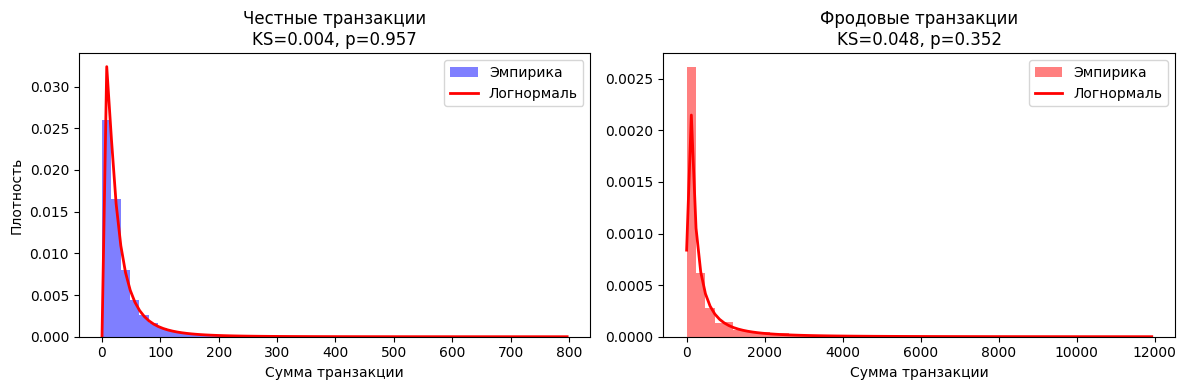

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Честные
axes[0].hist(honest, bins=50, density=True, alpha=0.5, color='blue', label='Эмпирика')
x0 = np.linspace(min(honest), max(honest), 100)
axes[0].plot(x0, lognorm.pdf(x0, s=shape0, scale=scale0), 'r-', linewidth=2, label='Логнормаль')
axes[0].set_xlabel('Сумма транзакции')
axes[0].set_ylabel('Плотность')
axes[0].set_title(f'Честные транзакции\nKS={ks_honest:.3f}, p={p_honest:.3f}')
axes[0].legend()

# Фрод
axes[1].hist(fraud, bins=50, density=True, alpha=0.5, color='red', label='Эмпирика')
x1 = np.linspace(min(fraud), max(fraud), 100)
axes[1].plot(x1, lognorm.pdf(x1, s=shape1, scale=scale1), 'r-', linewidth=2, label='Логнормаль')
axes[1].set_xlabel('Сумма транзакции')
axes[1].set_title(f'Фродовые транзакции\nKS={ks_fraud:.3f}, p={p_fraud:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/distributions_fitted.png', dpi=150)
plt.show()

In [11]:
params = {
    "H0": {
        "mu": float(mu0),
        "sigma": float(sigma0),
        "shape": float(shape0),
        "scale": float(scale0)
    },
    "H1": {
        "mu": float(mu1),
        "sigma": float(sigma1),
        "shape": float(shape1),
        "scale": float(scale1)
    },
    "ks_test": {
        "honest_stat": float(ks_honest),
        "honest_pvalue": float(p_honest),
        "fraud_stat": float(ks_fraud),
        "fraud_pvalue": float(p_fraud)
    }
}

with open('../data/distribution_params.json', 'w') as f:
    json.dump(params, f, indent=4)

print("✅ Параметры сохранены в data/distribution_params.json")
print(f"\nИтоговые параметры для SPRT:")
print(f"  H0 (честные):   μ = {mu0:.4f}, σ = {sigma0:.4f}")
print(f"  H1 (фрод):      μ = {mu1:.4f}, σ = {sigma1:.4f}")

✅ Параметры сохранены в data/distribution_params.json

Итоговые параметры для SPRT:
  H0 (честные):   μ = 3.0029, σ = 1.0090
  H1 (фрод):      μ = 5.0639, σ = 1.5063
